# 11 - Streaming and Real-Time Processing

**Objective:** Implement IQ streaming, on-FPGA averaging, and real-time decimation. This notebook covers:
- Streaming mode for continuous IQ data capture
- On-FPGA averaging for noise reduction
- Real-time decimation to reduce data bandwidth
- Comparison of streaming vs. buffered readout modes

## 1. Setup

In [1]:
# Standard imports
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import logging
from scipy import signal

from qick import *
from qick.asm_v2 import AveragerProgramV2

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(levelname)-8s [%(filename)s:%(lineno)d] %(message)s')

# Connect to the board
BITSTREAM_PATH = 'qick_216.bit'#'/path/to/your/firmware.bit'  # <--- CHANGE THIS
soc = QickSoc(BITSTREAM_PATH)
soccfg = soc

# Define hardware channels
GEN_CH = 0
RO_CH = 0

print("Ready")

Ready


## 2. Streaming Mode Overview

By default, the QICK captures readout data in **buffered mode**, where data is stored in on-board memory and transferred after the experiment. 

**Streaming mode** continuously streams IQ data from the ADC to the host computer in real-time. This is useful for:
- Monitoring signals over long periods
- Real-time feedback and decision making
- Capturing transient events
- High-throughput experiments

The trade-off: streaming generates large amounts of data and requires high-bandwidth communication.

## 3. Basic Streaming Example

Let's configure a simple streaming acquisition.

INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tproc.py:695] tProc pmem: readback OK


  0%|          | 0/1 [00:00<?, ?it/s]

INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP


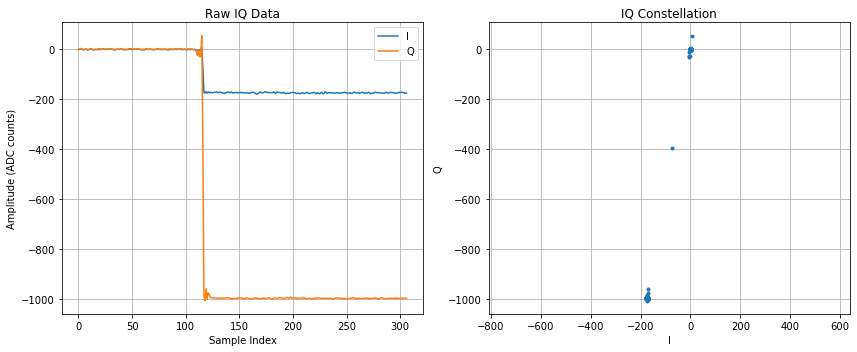

Total samples captured: 307


In [2]:
class StreamingProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['pulse_len'])
        
        self.add_pulse(
            ch=cfg['gen_ch'], name="test_pulse",
            style="const",
            freq=cfg['freq'], length=cfg['pulse_len'],
            phase=0, gain=cfg['gain']
        )
        self.add_readoutconfig(ch=cfg['ro_ch'], name="ro",
                               freq=cfg['freq'], gen_ch=cfg['gen_ch'])
        self.send_readoutconfig(ch=cfg['ro_ch'], name="ro", t=0)

    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="test_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=0.035)

config_stream = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500.0,
    'pulse_len': 1.0,
    'gain': 0.5,
}

prog = StreamingProgram(soccfg, reps=1, final_delay=0.5, cfg=config_stream)

# acquire_decimated returns the IQ samples over time.
iq_list = prog.acquire_decimated(soc, rounds=1)
# iq_list[ro_ch] tiene shape (samples, 2) -> columna 0=I, columna 1=Q
i_data = iq_list[0][:, 0]
q_data = iq_list[0][:, 1]

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(i_data, label='I')
plt.plot(q_data, label='Q')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude (ADC counts)')
plt.title('Raw IQ Data')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(i_data, q_data, '.')
plt.xlabel('I')
plt.ylabel('Q')
plt.title('IQ Constellation')
plt.axis('equal')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Total samples captured: {len(i_data)}")

## 4. Decimation in Streaming Mode

Decimation reduces the data rate by averaging or downsampling. This is crucial for long experiments where you don't need the full sample rate.

INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tproc.py:695] tProc pmem: readback OK
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tproc.py:695] tProc pmem: readback OK
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tpr

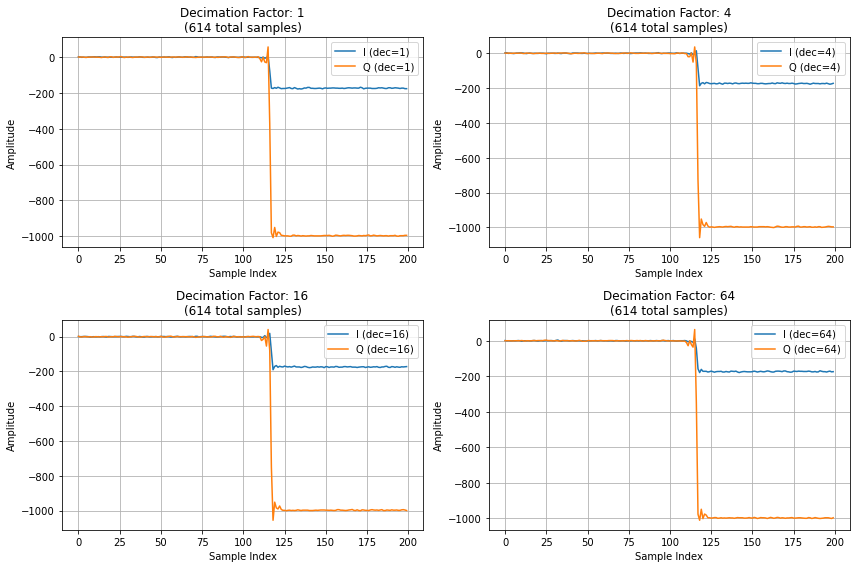

Decimation Summary:
  dec=1: 614 samples
  dec=4: 614 samples
  dec=16: 614 samples
  dec=64: 614 samples


In [3]:
decimations = [1, 4, 16, 64]
results = {}

for dec in decimations:
    config = config_stream.copy()
    config['pulse_len'] = 2.0

    prog = StreamingProgram(soccfg, reps=1, final_delay=0.5, cfg=config)
    iq_list = prog.acquire_decimated(soc, rounds=1, progress=False)
    results[dec] = {
        'i': iq_list[0][:, 0],
        'q': iq_list[0][:, 1],
    }

plt.figure(figsize=(12, 8))
for idx, dec in enumerate(decimations):
    plt.subplot(2, 2, idx+1)
    data = results[dec]
    samples_to_plot = min(200, len(data['i']))
    plt.plot(data['i'][:samples_to_plot], label=f'I (dec={dec})')
    plt.plot(data['q'][:samples_to_plot], label=f'Q (dec={dec})')
    plt.xlabel('Sample Index')
    plt.ylabel('Amplitude')
    plt.title(f'Decimation Factor: {dec}\n({len(data["i"])} total samples)')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

print("Decimation Summary:")
for dec in decimations:
    print(f"  dec={dec}: {len(results[dec]['i'])} samples")

## 5. Real-Time Averaging

The QICK FPGA can perform on-the-fly averaging of multiple shots. This reduces noise without transferring all raw data to the host.

In [8]:
print("iq_avg[0] shape:", iq_avg[0].shape)
print("time_axis shape:", time_axis.shape)
print("reps_per_round:", reps_per_round)
print("n_rounds:", n_rounds)
print("f_output:", soccfg['readouts'][RO_CH]['f_output'], "MHz")
print("buf_maxlen:", buf_maxlen)
print("samples_per_rep:", samples_per_rep)

iq_avg[0] shape: (6, 154, 2)
time_axis shape: (154,)
reps_per_round: 6
n_rounds: 16
f_output: 307.2 MHz
buf_maxlen: 1024
samples_per_rep: 153


INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tproc.py:695] tProc pmem: readback OK
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [t

Raw ADC rate:      2457.6 MHz
Decimated rate:    307.2 MHz
ro_len:            2.0 µs
Samples per rep:   614
Buffer max:        1024 samples
Max reps:          1
Using reps=1, rounds=100


INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:

iq_avg type: <class 'list'>
iq_avg length: 1
iq_avg[0] shape: (614, 2)
data_avg shape: (614, 2)


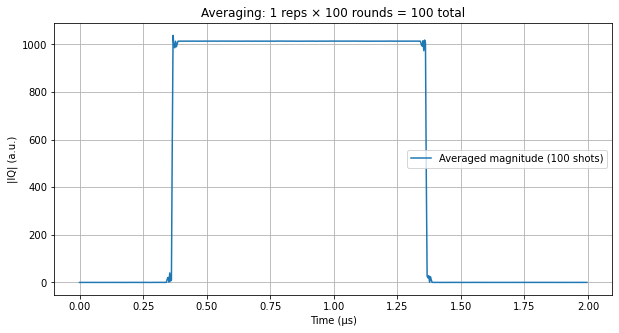

Data shape after averaging: (614, 2)
Mean magnitude: 506.9764
Peak magnitude: 1037.8815
Time range: 0.000 – 1.995 µs


In [13]:
class AveragingProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])
        
        self.add_pulse(ch=cfg['gen_ch'], name="test_pulse",
                       style="const",
                       freq=cfg['freq'], length=cfg['pulse_len'],
                       phase=0, gain=cfg['gain'])
        self.add_readoutconfig(ch=cfg['ro_ch'], name="my_ro",
                               freq=cfg['freq'], gen_ch=cfg['gen_ch'])

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)  # move here
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.pulse(ch=cfg['gen_ch'], name="test_pulse", t=0)
        
config_avg = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500.0,
    'pulse_len': 1.0,   # longer pulse so it fills the readout window
    'gain': 0.5,
    'trig_time': 0.05,  # keep small — trigger early, capture the turn-on transient
    'ro_len': 2.0,      # longer window to see full pulse + ringdown
    'avg_rounds': 100
}

# Calculate the maximum number of reps that fit in the buffer.
buf_maxlen = soccfg['readouts'][RO_CH]['buf_maxlen']

# Use f_output (decimated rate), not fs (raw ADC rate)
f_output = soccfg['readouts'][RO_CH]['f_output']  # MHz, after decimation
samples_per_rep = int(config_avg['ro_len'] * f_output)

print(f"Raw ADC rate:      {soccfg['readouts'][RO_CH]['fs']} MHz")
print(f"Decimated rate:    {f_output} MHz")
print(f"ro_len:            {config_avg['ro_len']} µs")
print(f"Samples per rep:   {samples_per_rep}")
print(f"Buffer max:        {buf_maxlen} samples")

max_reps = buf_maxlen // max(samples_per_rep, 1)  # guard against zero
print(f"Max reps:          {max_reps}")

# Clamp reps to buffer limit, then compute rounds to hit avg_rounds total
reps_per_round = max(1, min(config_avg['avg_rounds'], max_reps))
n_rounds = max(1, config_avg['avg_rounds'] // reps_per_round)
print(f"Using reps={reps_per_round}, rounds={n_rounds}")

prog = AveragingProgram(soccfg, reps=reps_per_round, final_delay=0.5, cfg=config_avg)
iq_avg = prog.acquire_decimated(soc, rounds=n_rounds, progress=False)

print("iq_avg type:", type(iq_avg))
print("iq_avg length:", len(iq_avg))
print("iq_avg[0] shape:", np.array(iq_avg[0]).shape)

# acquire_decimated returns list of arrays, one per ro_ch
# shape is typically (reps, n_samples, 2) — need to average over reps first
data = np.array(iq_avg[0])

if data.ndim == 3:
    # (reps, n_samples, 2) → average over reps
    data_avg = data.mean(axis=0)        # (n_samples, 2)
elif data.ndim == 2 and data.shape[-1] == 2:
    # already (n_samples, 2) — no averaging needed
    data_avg = data
elif data.ndim == 2 and data.shape[-1] != 2:
    # (reps, 2) — single sample per rep, not time-resolved
    data_avg = data.mean(axis=0, keepdims=True)  # (1, 2)
else:
    raise ValueError(f"Unexpected data shape: {data.shape}")

print("data_avg shape:", data_avg.shape)

magnitude = np.abs(data_avg[:, 0] + 1j * data_avg[:, 1])
time_axis = prog.get_time_axis(ro_index=0)

# Trim to matching length if needed
n = min(len(time_axis), len(magnitude))
plt.figure(figsize=(10, 5))
plt.plot(time_axis[:n], magnitude[:n],
         label=f'Averaged magnitude ({reps_per_round * n_rounds} shots)')
plt.xlabel('Time (µs)')
plt.ylabel('|IQ| (a.u.)')
plt.title(f'Averaging: {reps_per_round} reps × {n_rounds} rounds = {reps_per_round * n_rounds} total')
plt.legend()
plt.grid(True)
plt.show()

print(f"Data shape after averaging: {data_avg.shape}")
print(f"Mean magnitude: {magnitude.mean():.4f}")
print(f"Peak magnitude: {magnitude.max():.4f}")
print(f"Time range: {time_axis[0]:.3f} – {time_axis[-1]:.3f} µs")

## 6. Streaming vs. Buffered Readout Comparison

Understanding the difference between streaming and buffered modes helps you choose the right approach for your experiment.

INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tproc.py:695] tProc pmem: readback OK
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tproc.py:695] tProc pmem: readback OK
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP


f_output: 307.2 MHz
Buffer: 1024, samples/rep: 184, max_reps: 5
Single shape: (184, 2), Avg shape: (184, 2)


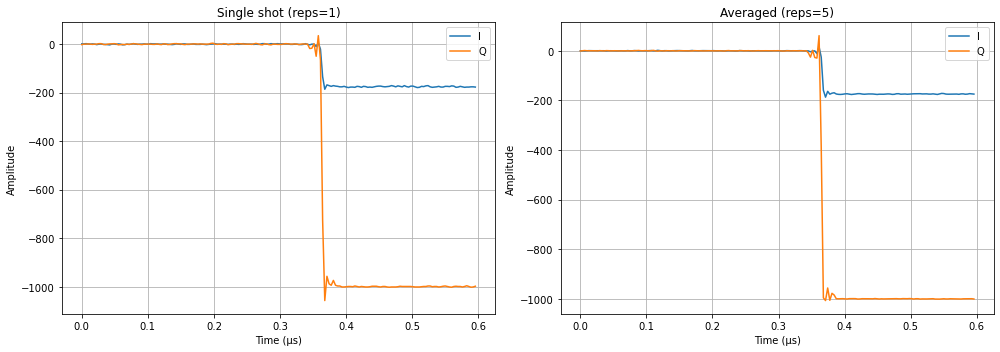

In [18]:
def compare_modes():

    class BufferCompare(AveragerProgramV2):
        def _initialize(self, cfg):
            self.declare_gen(ch=cfg['gen_ch'], nqz=1)
            self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])
            self.add_pulse(ch=cfg['gen_ch'], name="pulse",
                           style="const", freq=cfg['freq'],
                           length=cfg['pulse_len'], phase=0, gain=cfg['gain'])
            self.add_readoutconfig(ch=cfg['ro_ch'], name="my_ro",
                                   freq=cfg['freq'], gen_ch=cfg['gen_ch'])

        def _body(self, cfg):
            self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)
            self.pulse(ch=cfg['gen_ch'], name="pulse", t=0)
            self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

    common_config = {
        'gen_ch': GEN_CH,
        'ro_ch': RO_CH,
        'freq': 500.0,
        'pulse_len': 0.5,
        'gain': 0.5,
        'ro_len': 0.6,
        'trig_time': 0.05
    }

    # Correct buffer and sample rate calculation
    buf_maxlen      = soccfg['readouts'][RO_CH]['buf_maxlen']   # 1024 for acquire_decimated
    f_output        = soccfg['readouts'][RO_CH]['f_output']     # decimated rate MHz
    samples_per_rep = int(common_config['ro_len'] * f_output)
    max_reps        = max(1, buf_maxlen // samples_per_rep)
    print(f"f_output: {f_output} MHz")
    print(f"Buffer: {buf_maxlen}, samples/rep: {samples_per_rep}, max_reps: {max_reps}")

    # Single rep
    prog_single = BufferCompare(soccfg, reps=1, final_delay=0.5, cfg=common_config)
    iq_single   = prog_single.acquire_decimated(soc, rounds=1, progress=False)

    # Max reps
    prog_avg = BufferCompare(soccfg, reps=max_reps, final_delay=0.5, cfg=common_config)
    iq_avg   = prog_avg.acquire_decimated(soc, rounds=1, progress=False)

    # Normalize shapes — could be (reps, n_samples, 2) or (n_samples, 2)
    def to_2d(data):
        d = np.array(data)
        if d.ndim == 3:
            return d.mean(axis=0)   # average over reps → (n_samples, 2)
        return d                    # already (n_samples, 2)

    single = to_2d(iq_single[0])   # (n_samples, 2)
    avg    = to_2d(iq_avg[0])      # (n_samples, 2)

    print(f"Single shape: {single.shape}, Avg shape: {avg.shape}")

    time_single = prog_single.get_time_axis(ro_index=0)
    time_avg    = prog_avg.get_time_axis(ro_index=0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(time_single, single[:, 0], label='I')
    axes[0].plot(time_single, single[:, 1], label='Q')
    axes[0].set_xlabel('Time (µs)')
    axes[0].set_ylabel('Amplitude')
    axes[0].set_title('Single shot (reps=1)')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(time_avg, avg[:, 0], label='I')
    axes[1].plot(time_avg, avg[:, 1], label='Q')
    axes[1].set_xlabel('Time (µs)')
    axes[1].set_ylabel('Amplitude')
    axes[1].set_title(f'Averaged (reps={max_reps})')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

    return single, avg

single_data, avg_data = compare_modes()

## 7. Practical Application: Power Monitoring from Buffered Acquisition

Decimated readout data can be analyzed to estimate signal power and detect threshold crossings. 
This example demonstrates how to compute instantaneous power from IQ samples and identify events of interest.

INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc pmem: loading data
INFO     [tproc.py:695] tProc pmem: readback OK
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [t

Decimated rate:  307.2 MHz
Samples per rep: 614
Buffer max:      1024 samples
Max reps:        1
Using reps=1, rounds=100 (100 total shots)


INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:512] PROCESSOR_START
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:662] tProc wmem: loading data
INFO     [tproc.py:695] tProc wmem: readback OK
INFO     [tproc.py:524] PROCESSOR_RESET
INFO     [tproc.py:515] PROCESSOR_STOP
INFO     [tproc.py:5

Raw data shape: (614, 2)


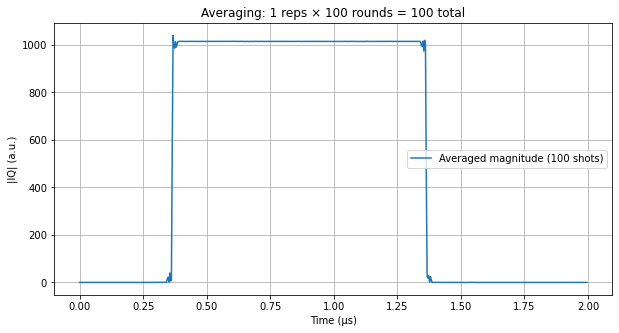

Data shape: (614, 2)
Time range: 0.000 – 1.995 µs
Mean magnitude: 507.3328
Peak magnitude: 1039.8059


In [17]:
class AveragingProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        self.declare_gen(ch=cfg['gen_ch'], nqz=1)
        self.declare_readout(ch=cfg['ro_ch'], length=cfg['ro_len'])
        
        self.add_pulse(ch=cfg['gen_ch'], name="test_pulse",
                       style="const",
                       freq=cfg['freq'], length=cfg['pulse_len'],
                       phase=0, gain=cfg['gain'])
        self.add_readoutconfig(ch=cfg['ro_ch'], name="my_ro",
                               freq=cfg['freq'], gen_ch=cfg['gen_ch'])

    def _body(self, cfg):
        self.send_readoutconfig(ch=cfg['ro_ch'], name="my_ro", t=0)  # moved here
        self.pulse(ch=cfg['gen_ch'], name="test_pulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])

config_avg = {
    'gen_ch': GEN_CH,
    'ro_ch': RO_CH,
    'freq': 500.0,
    'pulse_len': 1.0,
    'gain': 0.5,
    'trig_time': 0.05,
    'ro_len': 2.0,
    'avg_rounds': 100
}

buf_maxlen    = soccfg['readouts'][RO_CH]['buf_maxlen']   # samples
f_output      = soccfg['readouts'][RO_CH]['f_output']     # MHz — decimated rate
samples_per_rep = int(config_avg['ro_len'] * f_output)    # correct rate

print(f"Decimated rate:  {f_output} MHz")
print(f"Samples per rep: {samples_per_rep}")
print(f"Buffer max:      {buf_maxlen} samples")

if samples_per_rep > buf_maxlen:
    # ro_len too long — clamp it
    max_ro_len = buf_maxlen / f_output
    print(f"WARNING: ro_len={config_avg['ro_len']} µs too long, "
          f"clamping to {max_ro_len:.3f} µs")
    config_avg['ro_len'] = max_ro_len
    samples_per_rep = buf_maxlen

max_reps = buf_maxlen // samples_per_rep
reps_per_round = max(1, min(config_avg['avg_rounds'], max_reps))
n_rounds = max(1, config_avg['avg_rounds'] // reps_per_round)
print(f"Max reps:        {max_reps}")
print(f"Using reps={reps_per_round}, rounds={n_rounds} "
      f"({reps_per_round * n_rounds} total shots)")

prog = AveragingProgram(soccfg, reps=reps_per_round, final_delay=0.5, cfg=config_avg)
iq_avg = prog.acquire_decimated(soc, rounds=n_rounds, progress=False)

data = np.array(iq_avg[0])
print("Raw data shape:", data.shape)

# Average over reps axis if present
if data.ndim == 3:
    data = data.mean(axis=0)   # (reps, n_samples, 2) → (n_samples, 2)

magnitude = np.abs(data[:, 0] + 1j * data[:, 1])
time_axis = prog.get_time_axis(ro_index=0)
n = min(len(time_axis), len(magnitude))

plt.figure(figsize=(10, 5))
plt.plot(time_axis[:n], magnitude[:n],
         label=f'Averaged magnitude ({reps_per_round * n_rounds} shots)')
plt.xlabel('Time (µs)')
plt.ylabel('|IQ| (a.u.)')
plt.title(f'Averaging: {reps_per_round} reps × {n_rounds} rounds '
          f'= {reps_per_round * n_rounds} total')
plt.legend()
plt.grid(True)
plt.show()

print(f"Data shape: {data.shape}")
print(f"Time range: {time_axis[0]:.3f} – {time_axis[n-1]:.3f} µs")
print(f"Mean magnitude: {magnitude.mean():.4f}")
print(f"Peak magnitude: {magnitude.max():.4f}")

## 8. Summary

You have learned:

* How to acquire IQ data using buffered (decimated) readout
* How decimation reduces data rate while preserving signal information
* How on-FPGA averaging reduces noise without host involvement
* The trade-offs between buffered acquisition and streaming approaches
* How to estimate signal power and detect threshold crossings from IQ data

**Key takeaways:**

* Buffered acquisition (`acquire_decimated`) is simple and effective for most measurements
* Decimation allows you to balance data rate and temporal resolution
* On-FPGA averaging is efficient for repetitive measurements
* Streaming enables continuous acquisition but requires a different programming model
* Power monitoring can be implemented from IQ data, even without true real-time streaming

**Next steps:** Proceed to [`12_DSP_Blocks_And_Correlators.ipynb`](./12_DSP_Blocks_And_Correlators.ipynb) to learn about advanced signal processing with DSP blocks and correlators.